| Name | GONZAGA, Aloysius Q. |
|---|---|
| ID Number | 2023100147 |
| Section | CEA_CPE_2A_STEM |

# Coding Assignment 2: Preprocessing and Feature Engineering

## Objectives
By the end of this activity, you will be able to:
1. Diagnose and correct real data-quality problems (disguised missing values, outliers, skew) in a leakage-free way for tabular data.
2. Apply and justify the correct feature-scaling and encoding strategy for numeric neural network input.
3. Engineer new, domain-informed tabular features and evaluate whether they add signal.
4. Apply analogous preprocessing (normalization, resizing, augmentation) to image data.
5. Engineer descriptive image features (gradient/edge-based, texture, and projection-based) as alternatives to raw pixel input.
6. Defend every preprocessing decision with evidence (a plot, a metric, or a stated assumption) rather than by default habit.

> **Scope note:** This activity covers **preprocessing and feature engineering only**. You are not required to train a neural network (or any other classifier) in this notebook — the only estimators used below (e.g., inside Task 7's wrapper method) are tools for feature *selection*, not final models.

## Datasets
This activity works with **two** datasets so you practice preprocessing and feature engineering on both **numerical/tabular** data and **image** data.

**Part A — Numerical dataset: Pima Indians Diabetes Dataset** (the same dataset from Assignment 1.1 — Exploratory Data Analysis)

**Description:** 768 patient records with 8 numeric medical predictor features and a binary target (`Outcome`: 1 = diabetic, 0 = non-diabetic).

**Direct download (already wired into the loader cell below):**
`https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv`

> **Continuity with Assignment 1.1.** In that activity you *identified* that `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI` use `0` as a disguised placeholder for missing data, and you visualized skew, outliers, and class imbalance. Part A of this activity picks up exactly where that one left off: now you will *act* on those findings — impute, scale, encode, engineer, and select.

**Part B — Image dataset: Olivetti Faces Dataset** (loaded via `sklearn.datasets.fetch_olivetti_faces`, downloaded automatically on first use)

**Description:** 400 grayscale face images (64×64 pixels, pixel values already scaled to [0, 1] by scikit-learn) from 40 subjects, 10 images per subject.

Run each loader cell below first — do not change it.

Write your program in each code cell as needed. Write your observations, decisions, and justifications in each markdown cell (create one if none is provided). **Every preprocessing choice in this notebook must be justified in writing** — "I used median imputation" is not sufficient; "I used median imputation because X is right-skewed (see Assignment 1.1 histogram) and the mean would be pulled by outliers" is.


<font color="red">Create a copy of this notebook and edit that copy. Do not make any alterations in this notebook. Anyone who will be caught editing this notebook will be automatically marked zero.</font>

In [ ]:
#Dataset Loader (please do not modify this part)
import pandas as pd
import numpy as np

columns = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
           "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"]

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
df = pd.read_csv(url, names=columns)

# NOTE: As established in Assignment 1.1, 0 is used as a placeholder for missing values
# in ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]. The line below
# performs that replacement ONCE, here, so every task in this notebook starts from the
# same, correctly-flagged NaNs. Do not undo this in your own cells.
zero_as_missing_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df[zero_as_missing_cols] = df[zero_as_missing_cols].replace(0, np.nan)

print(df.shape)
print("\nMissing values per column (0 -> NaN already applied):")
print(df.isna().sum())
df.head()


(768, 9)

Missing values per column (0 -> NaN already applied):
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [ ]:
#The following libraries cover everything you should need for this activity.
# If you need more packages, you can install them using pip.
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler,
    OrdinalEncoder, OneHotEncoder, PowerTransformer
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, mutual_info_classif, RFE
from sklearn.linear_model import LogisticRegression  # used only as an RFE ranking estimator (feature selection, not a final model)
from sklearn.decomposition import PCA

# Image-specific libraries (Part B)
from sklearn.datasets import fetch_olivetti_faces
from skimage.feature import hog
from skimage.filters import sobel
from skimage import exposure
from skimage.transform import resize, rotate

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


---
# Part A — Numerical Data (Pima Indians Diabetes)

## Task 1 — Data Preparation and Leakage-Free Splitting (5 pts)
Before any preprocessing statistic (a mean, a median, a min/max, a scaler) is computed, the dataset must be split into training and test sets. This is the **Golden Rule** of leakage-free preprocessing: any transformation that *learns* something from the data must learn it only from the training set.

1. Separate the features (`X`) from the target (`Outcome`, `y`).
2. Split into training (80%) and test (20%) sets. Stratify on `Outcome` and set `random_state=RANDOM_STATE`.
3. Report the class balance of `Outcome` in both the training and test splits.


In [ ]:
#Task 1

# Task 1.1
selected_features = ["Pregnancies", "Glucose", "BloodPressure",  "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]
X = df[selected_features]
y = df["Outcome"]

# Task 1.2
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state = RANDOM_STATE, stratify=y
)


print("Features Training_Shape: ", X_train.shape)
print("Features Test_Shape:     ", X_test.shape)
print("Target Training_Shape:   ", y_train.shape)
print("Target Test_Shape:       ", y_test.shape)


# Task 1.3
print("Training Class Balance:")
print(y_train.value_counts(normalize = True) * 100)

print("\nTest Class Balance:")
print(y_test.value_counts(normalize = True) * 100)

Features Training_Shape:  (614, 8)
Features Test_Shape:      (154, 8)
Target Training_Shape:    (614,)
Target Test_Shape:        (154,)
Training Class Balance:
Outcome
0    65.14658
1    34.85342
Name: proportion, dtype: float64

Test Class Balance:
Outcome
0    64.935065
1    35.064935
Name: proportion, dtype: float64


**Observation / Justification:**
Explain why the split happens first, and what would go wrong here specifically if you scaled or imputed before splitting.


***Observations and Procedures:***

   I separated the data using the functions I based on the [1.2] Preprocessing Notes, splitting it into 80% training data and 20% testing based on the instructions provided. Stratifying the data is cruical to maintain the proportion of the values to prevent imbalance on the training and testing data. The split used a random state of 42 based on the instructions provided, this is so that we can replicate the results when needed to.

   The split was done before any preprocessing because statistics such as means, medians, etc..., mshould only come from the training set. This prevents data leakage, where the information from the test could be biased or influenced by how the training data is prepared.

## Task 2 — Missing Value Imputation (5 pts)
`Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI` contain real missing data (the disguised zeros from Assignment 1.1). Neural networks cannot process `NaN` inputs directly, so this must be resolved.

1. Report the missingness percentage per affected column, computed on the **training set only**.
2. Impute using **at least three** strategies, each fit on the training set and applied to both train and test:
   - Mean imputation
   - Median imputation
   - A third strategy of your choice (e.g., `KNNImputer`, or median-by-`Outcome`-group)
3. Compare the resulting distributions (e.g., histograms) of at least one imputed column across strategies.


Glucose           0.651466
BloodPressure     3.745928
SkinThickness    28.501629
Insulin          47.231270
BMI               1.465798
dtype: float64








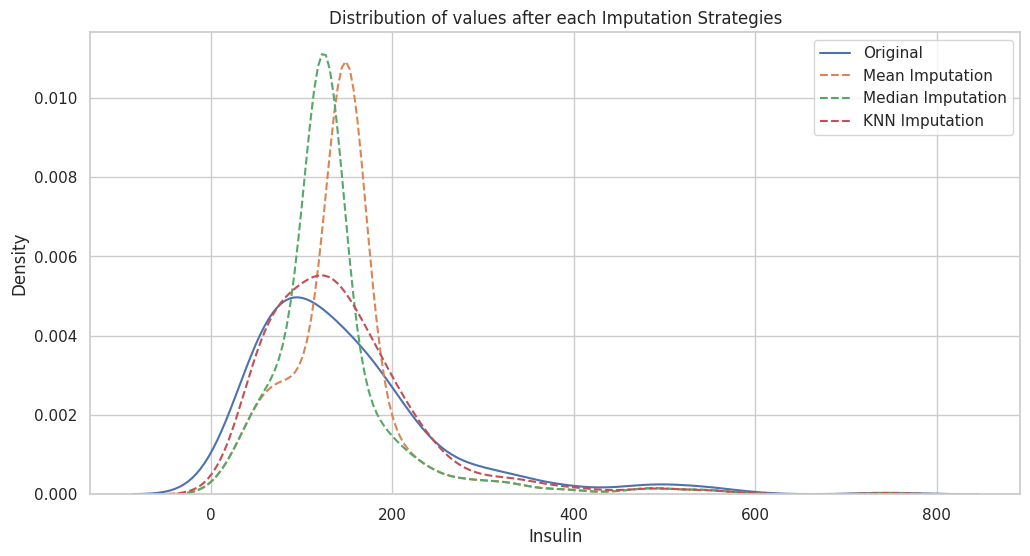

In [ ]:
#Task 2

# Based on the data from the setup code above
affected_missing_columns = ["Glucose", "BloodPressure", "SkinThickness","Insulin", "BMI"]

# Task 2.1
mising_value_percent = X_train[affected_missing_columns].isna().mean() * 100
print(mising_value_percent)
print("\n" * 5)


# Task 2.2
#Imputation:

# Mean
X_train_mean = X_train.fillna(X_train.mean())
X_test_mean = X_test.fillna(X_train.mean())

# Median
X_train_median = X_train.fillna(X_train.median())
X_test_median = X_test.fillna(X_train.median())

# KNN Imputer
knn_imputer = KNNImputer(n_neighbors = 5)
X_train_KNN = pd.DataFrame  (knn_imputer.fit_transform(X_train), columns = X_train.columns)
X_test_KNN = pd.DataFrame(knn_imputer.transform(X_test), columns = X_test.columns)



# Task 2.3
results = pd.DataFrame({
    "Original": X_train["Insulin"],
    "Mean Imputation": X_train_mean["Insulin"],
    "Median Imputation": X_train_median["Insulin"],
    "KNN Imputation": X_train_KNN["Insulin"],
})
results.describe()

# KDE plot comparing all values
fig,ax = plt.subplots(figsize = (12,6))
results = results.drop("Original", axis = 1)
sns.kdeplot(X_train["Insulin"], label="Original")

for col in results.columns:
    sns.kdeplot(results[col], label = col, linestyle="--")
ax.set_title("Distribution of values after each Imputation Strategies")
ax.legend()
plt.show()


# Using KNN Imputed for the following codes:
X_train_imp = X_train_KNN
X_test_imp = X_test_KNN

**Observation / Justification:**
Which imputation strategy did you choose to carry forward, and why — referencing the distribution shape and/or outliers of the affected column(s)?

***Observations and Proceedures:***

The amount of missing data was different across the affected variables. Insulin having the highest amount of missing values in the data set, which amounts to 47.23% of its values, followed by Skin thickness at about 28.5%, while the others -- Glucose, Blood Pressure, and BMI -- have lower percentage of missing values.
Due to some columns having a significant amount of missing values, deleting rows could remove too much data.

I compared the mean , median, and KNN imputation methods, and visualized it using a KDE plot to see how each of the imputation methods affects the resulting data. Using the results of the KDE plot, we can clearly see that the KNN has the least effect or the least change in the shape of data which could be beneficial since we don't want to alter the data too much. Choosing KNN may help preserve relationships between medical features and not alter too much on the data, although it is still an estimate and not a reliable solution for large data sets with high numbers of missing values.

- The mean imputation is quite vulnerable to outliers which is abundant in this data set, making the resulting value far askewed or altered from the original values with missing parts.

- The median imputation on the other hand is much more resilient to outliers but can still cause inaccuracies when the distribution of values is askewed.

- While KNN imputation is a much slower imputation method since it refers to the nearest neighbor of the data points, but it usually gives a more accurate or closer value measurement which could help us approximate the missing values and still be able to use the dataset. //

## Task 3 — Outlier Detection and Treatment (10 pts)
Using your **imputed training set** from Task 2:

1. Detect outliers in at least four numeric columns using **both** the IQR method and the Z-score method (`|z| > 3`). Report the count flagged by each method per column.
2. Visualize at least two of these columns with boxplots showing the IQR bounds.
3. For each flagged column, decide — and justify in writing — whether to **remove**, **cap/winsorize**, or **keep** the flagged points. Consider clinical plausibility, sample size, and the imputation strategy you chose in Task 2.
4. Apply your chosen treatment to the training set, and apply the **same, training-derived bounds** to the test set (never recompute bounds from the test set).


IQR Outliers: 
BloodPressure    13
SkinThickness     4
Insulin          30
BMI               7
dtype: int64


Z score outliers: 
BloodPressure     8
SkinThickness     2
Insulin          12
BMI               4
dtype: int64





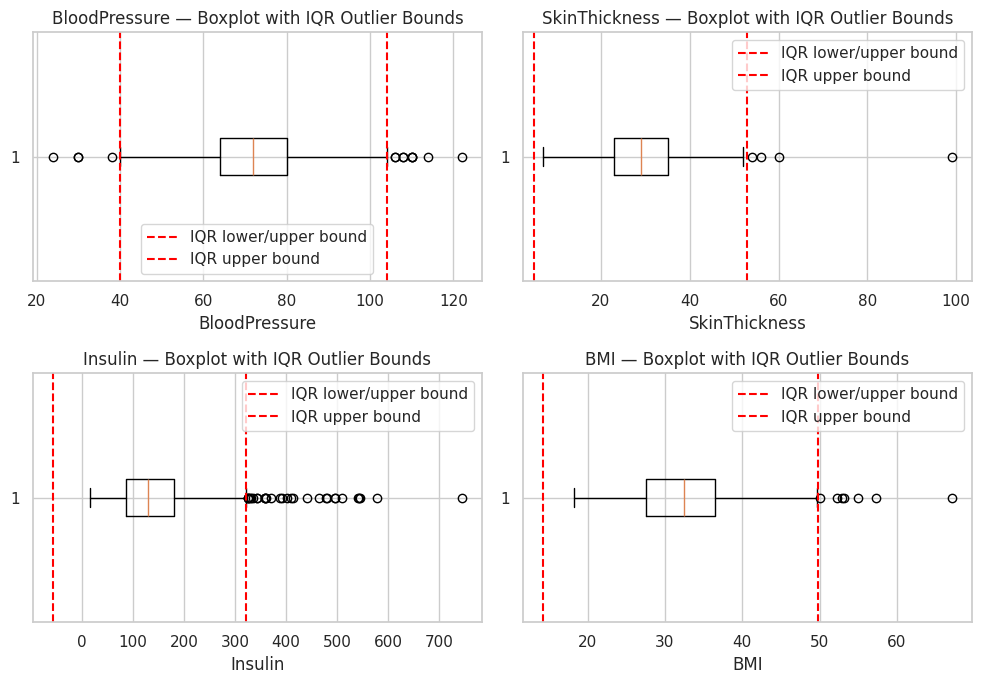

In [ ]:
#Task 3
selected_columns = ["BloodPressure", "SkinThickness","Insulin", "BMI"]
X_outlier = X_train_imp[selected_columns]

# Task 3.1
# IQR Method
Q1, Q3 = X_outlier.quantile(0.25), X_outlier.quantile(0.75)
IQR = Q3 - Q1
lower_bound, upper_bound = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
IQR_flags = ((X_outlier < lower_bound) | (X_outlier > upper_bound)).sum()


# Z-Score Method
z_score = (X_outlier - X_outlier.mean()) / X_outlier.std()
z_outliers = ((abs(z_score) > 3)).sum()


# Task 3.2
# Visualize
print("=" * 40)
print("IQR Outliers: ")
print(IQR_flags)
print("=" * 40)

print("\n")
print("=" * 40)
print("Z score outliers: ")
print(z_outliers)
print("=" * 40)

print("\n" * 2)


# Box plot Visualization
fig, axs = plt.subplots(2, 2, figsize = (10, 7))
i = 0

for col in selected_columns:
    row = i // 2
    column = i %  2
    ax = axs[row, column]

    ax.boxplot(X_outlier[col].dropna(), vert=False)
    ax.axvline(lower_bound[col], color="red", linestyle="--", label="IQR lower/upper bound")
    ax.axvline(upper_bound[col], color="red", linestyle="--", label="IQR upper bound")

    ax.set_title(f"{col} — Boxplot with IQR Outlier Bounds")
    ax.set_xlabel(col)
    ax.legend()

    i += 1

plt.tight_layout()
plt.show()


# Task 3.3
# Keeping the flagged points
"""
It would be safer to include/keep the outliers since the data is medical and the outliers are real medical cases recorded in real life.
"""

# Task 3.4
X_train_out = X_train_imp.copy()
X_test_out = X_test_imp.copy()



**Observation / Justification:**
For each treated column, explain your remove/cap/keep decision and why applying test-set-specific bounds would have been incorrect.


***Observation and Procedures:***

I used the IQR and Z-score methods to detect outliers and the boundary of data. Observing the results of the IQR and Z-score detection on outliers, we can see that the IQR detected more outliers than the Z-score method but this is an unfair comparison since both use different measurements as basis on its boundary. But using both are useful in certain cases which could help us treat these outliers and clean our data.


The decision I made on treating the column is to keep the outliers on the data, this is because the data set is a medical record of actual patients which the cases of outliers are possible in their situation. Keeping the data could mean considering these extreme medical cases which could potentially help a wider range of patients.

Since I decided to keep the outliers, I did not apply any bounds. If bounds were used, it should only be calculated from the training data because the testing data could be influenced if included in the bounds/preprocessing.

## Task 4 — Feature Scaling (10 pts)
Neural networks are highly sensitive to feature scale because every input is linearly combined in the very first layer, and gradient descent converges poorly on ill-conditioned, unscaled loss surfaces.

1. Fit `StandardScaler`, `MinMaxScaler`, and `RobustScaler` **on the training set only**.
2. Transform both train and test with each fitted scaler (three separate versions of the dataset).
3. Produce a before/after boxplot (raw vs. each scaled version) for at least two columns.


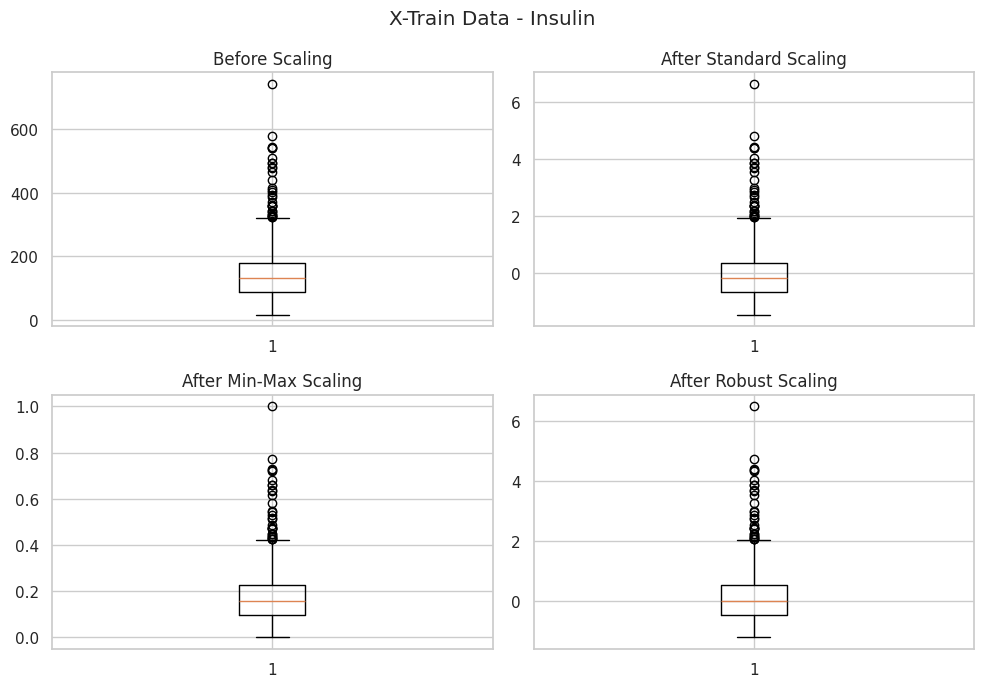

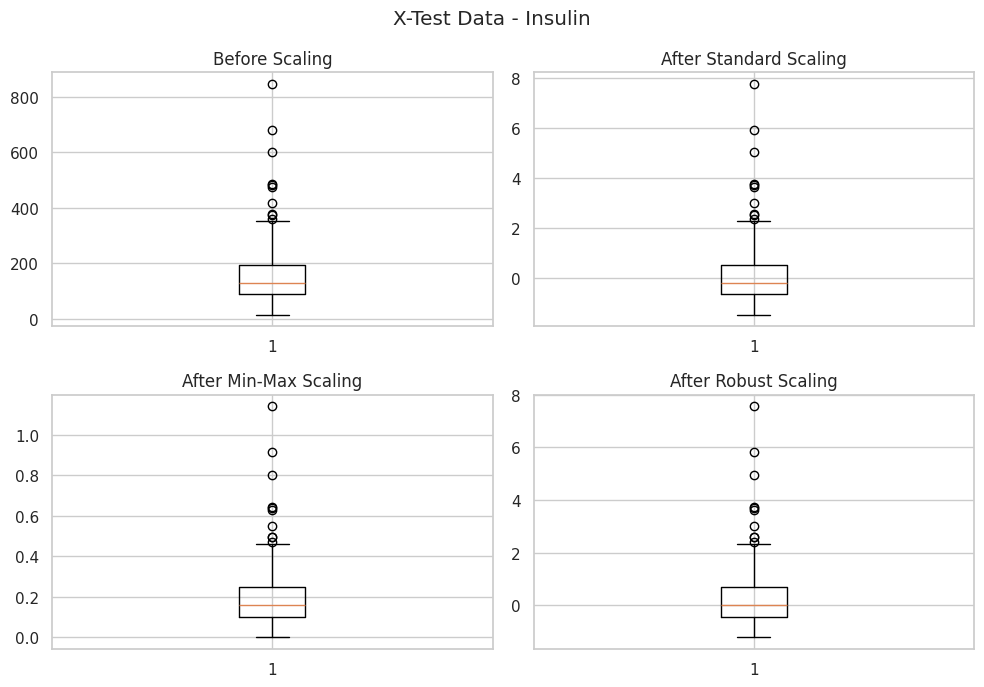

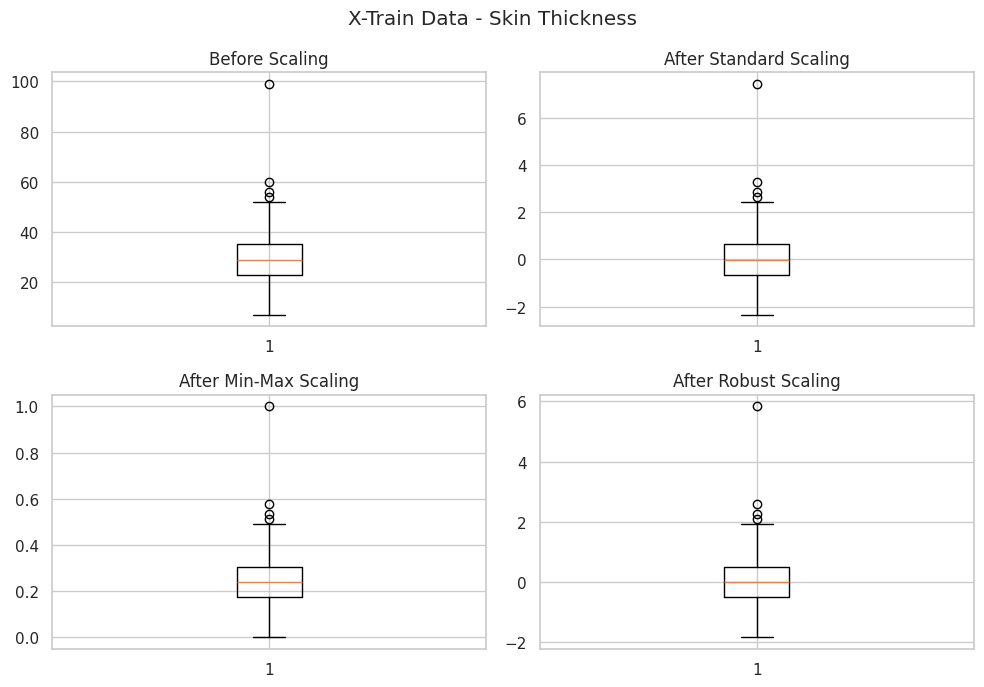

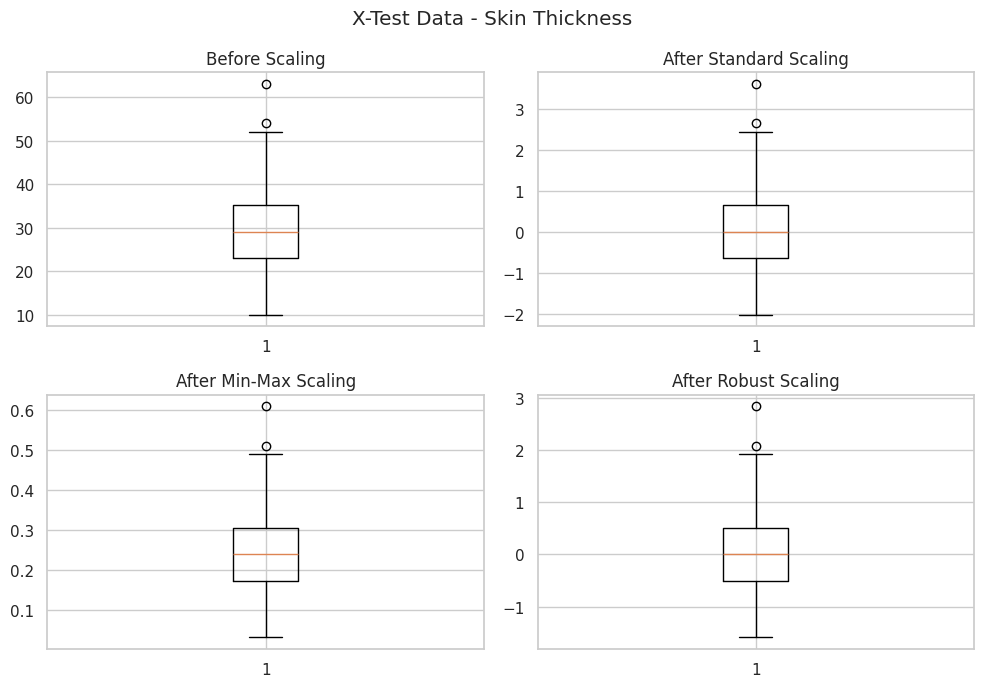

In [ ]:
#Task 4

# Task 4.1
# Standard Scaler
X_train_Scaler = StandardScaler().fit(X_train_out)

# Min-Max Scaler
X_train_MinMax = MinMaxScaler().fit(X_train_out)

# Robust Scaler
X_train_Robust = RobustScaler().fit(X_train_out)

# Task 4.2
X_train_std = X_train_Scaler.transform(X_train_out)
X_train_minmax = X_train_MinMax.transform(X_train_out)
X_train_robust = X_train_Robust.transform(X_train_out)

X_test_std = X_train_Scaler.transform(X_test_out)
X_test_minmax = X_train_MinMax.transform(X_test_out)
X_test_robust = X_train_Robust.transform(X_test_out)


X_train_std = pd.DataFrame(X_train_std, columns =  X_train_out.columns)
X_train_minmax = pd.DataFrame(X_train_minmax, columns = X_train_out.columns)
X_train_robust = pd.DataFrame(X_train_robust, columns = X_train_out.columns)

X_test_std = pd.DataFrame(X_test_std, columns = X_test_out.columns)
X_test_minmax = pd.DataFrame(X_test_minmax, columns = X_test_out.columns)
X_test_robust = pd.DataFrame(X_test_robust, columns = X_test_out.columns)



# Task 4.3
# Boxplot - Insulin
feature_1 = "Insulin"
feature_2 = "SkinThickness"

fig, ax = plt.subplots(2, 2, figsize = (10, 7))
ax[0, 0].boxplot(X_train_out[feature_1])
ax[0, 0].set_title("Before Scaling")

ax[0, 1].boxplot(X_train_std[feature_1])
ax[0, 1].set_title("After Standard Scaling")

ax[1, 0].boxplot(X_train_minmax[feature_1])
ax[1, 0].set_title("After Min-Max Scaling")

ax[1, 1].boxplot(X_train_robust[feature_1])
ax[1, 1].set_title("After Robust Scaling")

plt.suptitle("X-Train Data - Insulin")
plt.tight_layout()
plt.show()

print("\n" * 2)

fig, ax = plt.subplots(2, 2, figsize = (10, 7))
ax[0, 0].boxplot(X_test_out[feature_1])
ax[0, 0].set_title("Before Scaling")

ax[0, 1].boxplot(X_test_std[feature_1])
ax[0, 1].set_title("After Standard Scaling")

ax[1, 0].boxplot(X_test_minmax[feature_1])
ax[1, 0].set_title("After Min-Max Scaling")

ax[1, 1].boxplot(X_test_robust[feature_1])
ax[1, 1].set_title("After Robust Scaling")

plt.suptitle("X-Test Data - Insulin")
plt.tight_layout()
plt.show()

print("\n" * 4)

# Boxplot 2 - Skin Thickness
fig, ax = plt.subplots(2, 2, figsize = (10, 7))
ax[0, 0].boxplot(X_train_out[feature_2])
ax[0, 0].set_title("Before Scaling")

ax[0, 1].boxplot(X_train_std[feature_2])
ax[0, 1].set_title("After Standard Scaling")

ax[1, 0].boxplot(X_train_minmax[feature_2])
ax[1, 0].set_title("After Min-Max Scaling")

ax[1, 1].boxplot(X_train_robust[feature_2])
ax[1, 1].set_title("After Robust Scaling")

plt.suptitle("X-Train Data - Skin Thickness")
plt.tight_layout()
plt.show()

print("\n" * 2)

fig, ax = plt.subplots(2, 2, figsize = (10,7))
ax[0, 0].boxplot(X_test_out[feature_2])
ax[0, 0].set_title("Before Scaling")

ax[0, 1].boxplot(X_test_std[feature_2])
ax[0, 1].set_title("After Standard Scaling")

ax[1, 0].boxplot(X_test_minmax[feature_2])
ax[1, 0].set_title("After Min-Max Scaling")

ax[1, 1].boxplot(X_test_robust[feature_2])
ax[1, 1].set_title("After Robust Scaling")

plt.suptitle("X-Test Data - Skin Thickness")
plt.tight_layout()
plt.show()


**Observation / Justification:**
Which scaler did you choose to carry forward, and why — in light of your Task 3 outlier decisions?


***Observation and Procedures:***

I used and compared the different scaling methods which are StandardScaler, MinMaxScaler, and RobustScaler, to see how each method changes the scale of the selected features. Since the dataset uses different ranges of values and units, Scaling helps make the features more comparable and closer values to each other, preventing variables with large numerical values to influence smaller variables.


Among those three methods, I would prefer to use the Robust Scaler because I decided to keep the outliers from the previous task. Robust Scaler is much less affected by extreme values because it uses a more complex method to scale values instead of relying heavily on the mean, standard deviation, minimum, and maximum.

## Task 5 — Feature Engineering: Creation and Encoding (10 pts)
Feature engineering creates new predictive signal that did not exist as a raw column. Using the (imputed, outlier-treated) training data:

1. Engineer **at least three** new features using domain reasoning about diabetes risk factors, for example:
   - A `BMI_category` feature (e.g., underweight / normal / overweight / obese, using standard clinical BMI cutoffs)
   - A `Glucose_Insulin_ratio` feature
   - An `Age_group` feature (e.g., binned into decades)
2. Encode any categorical feature you created (ordinal or one-hot, whichever is appropriate) — fit the encoder on training data only.
3. Apply the exact same feature-construction logic and fitted encoder to the test set.


In [ ]:
#Task 5
X_train_fe = X_train_out.copy()
X_test_fe = X_test_out.copy()

# Task 5.1
# Glucose_Insulin_Ratio
X_train_fe["Glucose-Insulin_Ratio"] = ( X_train_fe["Glucose"] / X_train_fe["Insulin"] )
X_test_fe["Glucose-Insulin_Ratio"] = ( X_test_fe["Glucose"] / X_test_fe["Insulin"] )

# BloodPressure_Insulin_Ratio
X_train_fe["BloodPressure-Insulin_Ratio"] = ( X_train_fe["BloodPressure"] / X_train_fe["Insulin"] )
X_test_fe["BloodPressure-Insulin_Ratio"] = ( X_test_fe["BloodPressure"] / X_test_fe["Insulin"] )

# BMI_Category
BMI_bins = [0 , 18.5, 24.9, 29.9, np.inf]
BMI_labels = ["Underweight", "Normal", "Overweight", "Obese"]

X_train_fe["BMI_Category"] = pd.cut(X_train_fe["BMI"], bins = BMI_bins, labels = BMI_labels, right = False)


print("=" * 80)
print("New Added Features (Train): \n")
print(X_train_fe[["BMI_Category", "BloodPressure-Insulin_Ratio", "Glucose-Insulin_Ratio"]].head())
print("=" * 80)

print('\n')



# Task 5.2
BMI_encoder = OrdinalEncoder(categories = [BMI_labels])
X_train_fe["BMI_Category_encoded"] = BMI_encoder.fit_transform(X_train_fe[["BMI_Category"]])

X_train_fe = X_train_fe.drop("BMI_Category", axis = 1)

print("=" * 80)
print("New Encoded Features (Train): \n")
print(X_train_fe[["BMI_Category_encoded", "BloodPressure-Insulin_Ratio", "Glucose-Insulin_Ratio"]].head())
print("=" * 80)

print('\n')



# Task 5.3
# Glucose_Insulin_Ratio
X_test_fe["Glucose-Insulin_Ratio"] = ( X_test_fe["Glucose"] / X_test_fe["Insulin"] )

# BloodPressure_Insulin_Ratio
X_test_fe["BloodPressure-Insulin_Ratio"] = ( X_test_fe["BloodPressure"] / X_test_fe["Insulin"] )

# BMI_Category
X_test_fe["BMI_Category"] = pd.cut(X_test_fe["BMI"], bins = BMI_bins, labels = BMI_labels, right=False)
X_test_fe["BMI_Category_encoded"] = BMI_encoder.transform(X_test_fe[["BMI_Category"]])

X_test_fe = X_test_fe.drop("BMI_Category", axis = 1)

print("=" * 80)
print("New Added & Encoded Features (Test): \n")
print(X_test_fe[["BMI_Category_encoded", "BloodPressure-Insulin_Ratio", "Glucose-Insulin_Ratio"]].head())
print("=" * 80)


New Added Features (Train): 

  BMI_Category  BloodPressure-Insulin_Ratio  Glucose-Insulin_Ratio
0   Overweight                     1.441860               2.093023
1   Overweight                     3.545455               5.727273
2        Obese                     0.617021               1.117021
3   Overweight                     0.422323               1.101056
4        Obese                     0.609524               0.904762


New Encoded Features (Train): 

   BMI_Category_encoded  BloodPressure-Insulin_Ratio  Glucose-Insulin_Ratio
0                   2.0                     1.441860               2.093023
1                   2.0                     3.545455               5.727273
2                   3.0                     0.617021               1.117021
3                   2.0                     0.422323               1.101056
4                   3.0                     0.609524               0.904762


New Added & Encoded Features (Test): 

   BMI_Category_encoded  BloodPressur

**Observation / Justification:**
For each engineered feature, briefly state the medical/domain reasoning behind it, and explain your encoding choice (ordinal vs. one-hot) for any categorical feature you created.


***Observation and Procedure:***

I added three new features on the data set to differentiate subcategories and add new relationships which could help us analyze the data more clearly. BMI_Category made subcategories which help group patients based on their BMI values. I also added Glucose-Insulin_Ratio and BloodPressure-Insulin_Ratio to represent the relationship between the two values, instead of calculating separately each time.

I used OrdinalEncoder for the BMI_Category because BMI has a natural order from underweight up to obese.
I did not use one-hot encoding because the categories I added/made are ordered and not completely separate from each other.

asdsjhjkhk## Task 6 — Feature Transformation for Skew (10 pts)
Recall from Assignment 1.1 that some features (commonly `Insulin`, `SkinThickness`, `DiabetesPedigreeFunction`) are right-skewed.

1. Quantify skewness (`scipy.stats.skew` or `pandas.Series.skew`) for every numeric feature on the training set.
2. Pick the two most skewed features and apply **two** different transformations to each: a `log1p` transform and a `PowerTransformer` (Yeo-Johnson, which tolerates zeros).
3. Report the skewness value before and after each transformation, and visualize with histograms.


Skewness of Features (Train):

Pregnancies                    0.886920
Glucose                        0.554133
BloodPressure                  0.098057
SkinThickness                  0.746424
Insulin                        2.025859
BMI                            0.576065
DiabetesPedigreeFunction       1.818910
Age                            1.128456
Glucose-Insulin_Ratio          3.586254
BloodPressure-Insulin_Ratio    3.055186
BMI_Category_encoded          -1.152247
dtype: float64



Skewness Values Report 

1. Feature:  Glucose-Insulin_Ratio
Original:  3.586254020640814
Log1p:  1.5406857730427765
Yeo-Johnson:  -0.020496582960469488


2. Feature:  BloodPressure-Insulin_Ratio
Original:  3.0551858967905043
Log1p:  1.4891856260287821
Yeo-Johnson:  0.05513101070567369


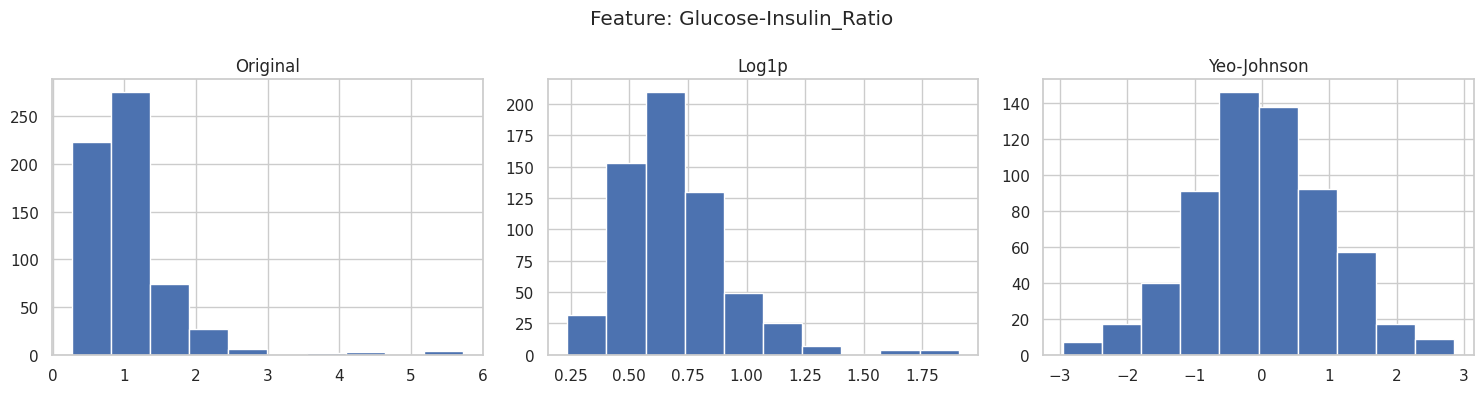

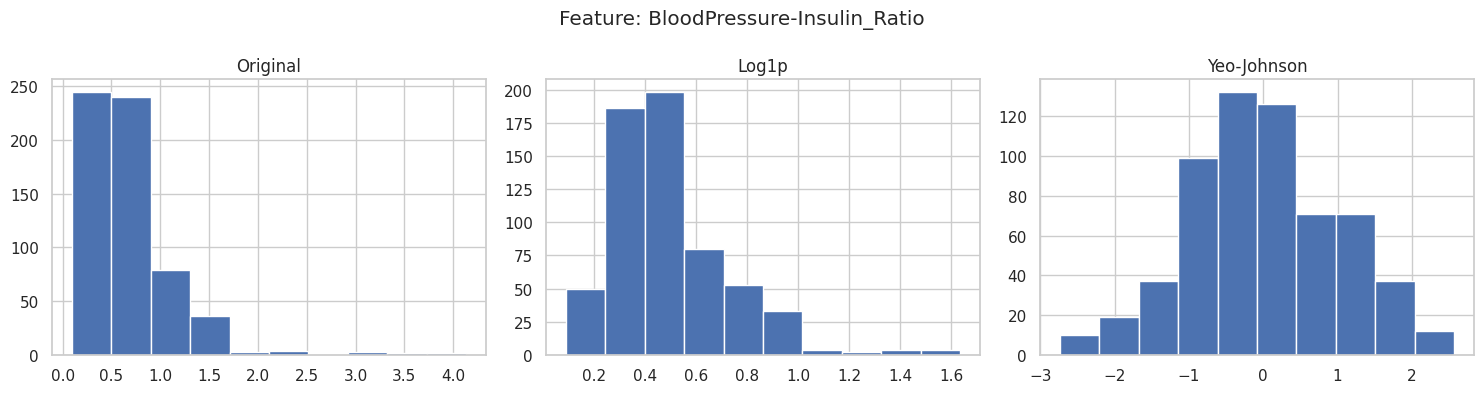

In [ ]:
#Task 6

# Task 6.1
skew_values = X_train_fe.skew(numeric_only=True)

print("=" * 70)
print("Skewness of Features (Train):\n")
print(skew_values)
print("=" * 70)

print("\n" * 2)

# Task 6.2
# Numpy logarithmic
X_train_log = X_train_fe.copy()
X_test_log = X_test_fe.copy()

feature_1 = "Glucose-Insulin_Ratio"
feature_2 = "BloodPressure-Insulin_Ratio"

X_train_log[feature_1] = np.log1p(X_train_log[feature_1])
X_test_log[feature_1] = np.log1p(X_test_log[feature_1])

X_train_log[feature_2] = np.log1p(X_train_log[feature_2])
X_test_log[feature_2] = np.log1p(X_test_log[feature_2])

# Yeo-Johnson Power Transformer
X_train_yeo = X_train_fe.copy()
X_test_yeo = X_test_fe.copy()

power_trans_1 = PowerTransformer(
    method="yeo-johnson"
)
power_trans_2 = PowerTransformer(
    method="yeo-johnson"
)

X_train_yeo[feature_1] = power_trans_1.fit_transform(X_train_yeo[[feature_1]]).ravel()
X_test_yeo[feature_1] = power_trans_1.transform(X_test_yeo[[feature_1]]).ravel()

X_train_yeo[feature_2] = power_trans_2.fit_transform(X_train_yeo[[feature_2]]).ravel()
X_test_yeo[feature_2] = power_trans_2.transform(X_test_yeo[[feature_2]]).ravel()

# Task 6.3
# Skewness Report
print("=" * 70)
print("Skewness Values Report \n")


print("1. Feature: ", feature_1)
print("Original: ", X_train_fe[feature_1].skew())
print("Log1p: ", X_train_log[feature_1].skew())
print("Yeo-Johnson: ", X_train_yeo[feature_1].skew())

print("\n")

print("2. Feature: ", feature_2)
print("Original: ", X_train_fe[feature_2].skew())
print("Log1p: ", X_train_log[feature_2].skew())
print("Yeo-Johnson: ", X_train_yeo[feature_2].skew())
print("=" * 70)


# Histogram
# Feature 1
fig, ax = plt.subplots(1, 3, figsize = (15, 4))
fig.suptitle(f"Feature: {feature_1}")

ax[0].set_title("Original")
ax[0].hist(X_train_fe[feature_1])

ax[1].set_title("Log1p")
ax[1].hist(X_train_log[feature_1])

ax[2].set_title("Yeo-Johnson")
ax[2].hist(X_train_yeo[feature_1])

plt.tight_layout()
plt.show()

print("\n" * 2)

# Feature 2
fig, ax = plt.subplots(1, 3, figsize = (15, 4))
fig.suptitle(f"Feature: {feature_2}")

ax[0].set_title("Original")
ax[0].hist(X_train_fe[feature_2])

ax[1].set_title("Log1p")
ax[1].hist(X_train_log[feature_2])

ax[2].set_title("Yeo-Johnson")
ax[2].hist(X_train_yeo[feature_2])

plt.tight_layout()
plt.show()


# Keeping the yeo-johnson transformation for the next task/s
X_train_current = X_train_yeo
X_test_current = X_test_yeo


**Observation / Justification:**
Which transformation reduced skew the most for your chosen feature(s), and are you keeping it? Why or why not?

Using histograms and print lines of the .skew() function, I compared the performance or outcome of the Log1p method and the Yeo-Johnson method. Both transformations reduced skewness on the data, but the graph shows clearly that the Yeo-Johnson has the most impact on its skewness.
The Yeo-Johnson method made the values inside closer to the value zero, which means that the distributions are more symmetric across the values, observed in the histogram of Glucose-Insulin_Ratio and BLoodPressure-Insulin_Ratio.

The Tranformation I kept in this task is the Yeo-Johnson method because of its performance in the histograms and data I tested.

## Task 7 — Feature Selection (10 pts)
More features are not automatically better — extra, uninformative dimensions can dilute signal and increase overfitting risk, especially on a dataset this size (768 rows).

1. Apply a **filter method**: rank all current features (raw + engineered) by mutual information with `Outcome` using `SelectKBest(score_func=mutual_info_classif)`, fit on the training set only.
2. Apply a **wrapper method**: use `RFE` with a `LogisticRegression` estimator (used here purely as a ranking tool for feature selection, not as a final model) to select the same number of features.
3. Compare the two selected feature sets.


In [ ]:
#Task 7

# Task 7.1
X_train_sel = X_train_current.copy()
X_test_sel = X_test_current.copy()
k = 5

kbest_selector = SelectKBest(score_func=mutual_info_classif, k = 5)
kbest_selector.fit(X_train_sel, y_train)

MI_scores = pd.Series(
    kbest_selector.scores_,
    index = X_train_sel.columns
)

MI_scores = MI_scores.sort_values(
    ascending = False
)

MI_selected = X_train_current.columns[
    kbest_selector.get_support()
].tolist()

print("=" * 70)
print("Mutual Information Ranking:\n")
print(MI_scores)
print("=" * 70)



print("\n")

# Task 7.2
RFE_estimator = LogisticRegression(max_iter = 2000, random_state = RANDOM_STATE)
RFE_selector = RFE(estimator=RFE_estimator, n_features_to_select = k)
RFE_selector.fit(X_train_sel, y_train)

RFE_selected =  X_train_current.columns[RFE_selector.support_].tolist()


# Task 7.3

# Mutual Information
print("\n")
print("=" * 90)
print("Selected features using Mutual Information:\n")
print(MI_selected)
print("=" * 90)

# Recursive Feature Elimination
print("=" * 110)
print("Selected features using RFE:\n")
print(RFE_selected)
print("=" * 110)

print("\n")

common_features = []

for feature in MI_selected:
    if feature in RFE_selected:
        common_features.append(feature)


print("Features Selected by Both:")
print(common_features)
print("\n")


print(f"Number of Features They Agree On: {len(common_features)}")



X_train_MI = kbest_selector.transform(X_train_sel)
X_test_MI = kbest_selector.transform(X_test_sel)

X_train_RFE = RFE_selector.transform(X_train_sel)
X_test_RFE = RFE_selector.transform(X_test_sel)

Mutual Information Ranking:

Insulin                        0.135217
Glucose                        0.132259
BMI                            0.097761
BMI_Category_encoded           0.072426
BloodPressure-Insulin_Ratio    0.069980
Glucose-Insulin_Ratio          0.069096
Age                            0.056510
SkinThickness                  0.034565
Pregnancies                    0.027808
DiabetesPedigreeFunction       0.011512
BloodPressure                  0.000000
dtype: float64




Selected features using Mutual Information:

['Glucose', 'Insulin', 'BMI', 'BloodPressure-Insulin_Ratio', 'BMI_Category_encoded']
Selected features using RFE:

['Pregnancies', 'BMI', 'DiabetesPedigreeFunction', 'BloodPressure-Insulin_Ratio', 'BMI_Category_encoded']


Features Selected by Both:
['BMI', 'BloodPressure-Insulin_Ratio', 'BMI_Category_encoded']


Number of Features They Agree On: 3



# Part B — Image Data (Olivetti Faces)

The tasks below mirror the *type* of work you did in Part A (splitting, preprocessing, feature engineering) but applied to image data instead of tabular data. As in Part A, **no model is trained** in this section — the goal is producing clean, well-justified, leakage-free inputs and engineered feature representations.

Run the loader cell below first — do not change it.


**Observation / Justification:**
How much did the filter and wrapper methods agree? Which feature set are you using going forward, and why?

***Observation and Procedure:***
I compared the features selected by the Mutual Information method and the RFE. The two methods greatly differ in their ranking and selection of the variables/features, both only agrees on three features out of 5 features they both selected, which are BMI and BloodPressure-Insulin_Ratio. This shows that both methods select features differently because they use different ways of determining which features are important.

I would prefer to use the selected features of the Mutual Information because it included features, that when seen manually, that shows stronger relationships with the Outcome. However, the selected features of both methods are important nonetheless because both methods agreed on their respective choices, which can have different applications based on the differet results.

In [ ]:
#Image Dataset Loader (please do not modify this part)
from sklearn.datasets import fetch_olivetti_faces

faces = fetch_olivetti_faces(shuffle=True, random_state=RANDOM_STATE)
X_img = faces.data       # shape (400, 4096) — flattened 64x64 images, already scaled to [0, 1]
y_img = faces.target     # shape (400,) — subject id, 0-39
images = faces.images    # shape (400, 64, 64) — same data, 2D form, useful for plotting

print("Flattened data shape:", X_img.shape)
print("Image (2D) shape:", images.shape)
print("Number of subjects:", len(set(y_img)))
print("Pixel value range:", X_img.min(), "to", X_img.max())


downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data
Flattened data shape: (400, 4096)
Image (2D) shape: (400, 64, 64)
Number of subjects: 40
Pixel value range: 0.0 to 1.0


## Task 8 — Image Dataset Preparation and Leakage-Free Splitting (10 pts)
1. Split the image data into training (80%) and test (20%) sets, stratified on the subject label (`y_img`), with `random_state=RANDOM_STATE`. As in Part A, the split must happen before any preprocessing statistic (e.g., a normalization mean/std) is computed.
2. Report how many training and test images you ended up with, and confirm the split is stratified (e.g., show that most subjects appear in both sets).
3. Visualize a grid of at least 8 sample training images (use the 2D `images` array, e.g., `plt.imshow(img, cmap="gray")`) with their subject labels as titles.


Number of Training images:    320
Number of Test images:        80


Number of Training subjects:  40
Number of Test subjects:      40


Number of Subjects that appear n Both:   40


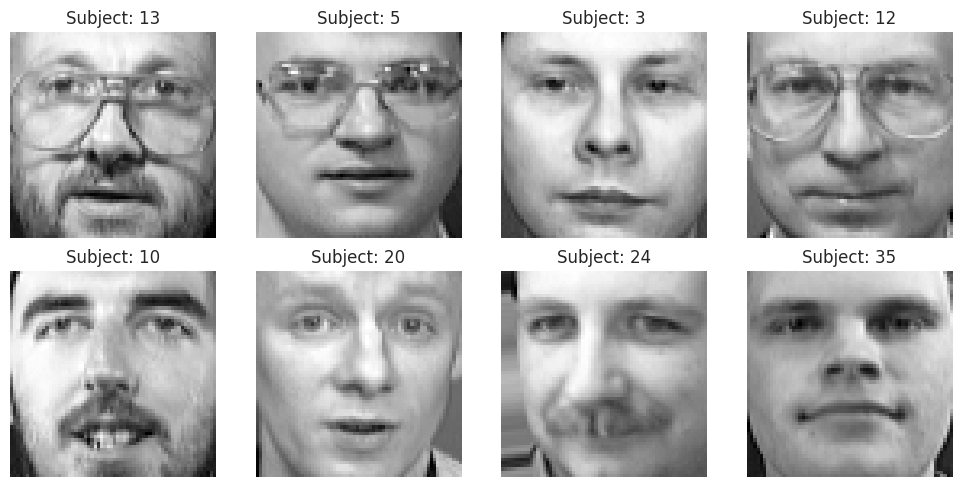

In [ ]:
#Task 8

# Task 8.1
X_train_img, X_test_img, y_train_img, y_test_img = train_test_split(
    X_img,
    y_img,
    test_size = 0.2,
    stratify = y_img,
    random_state = RANDOM_STATE
)

images_train, images_test = train_test_split(
    images,
    test_size = 0.2,
    stratify = y_img,
    random_state = RANDOM_STATE
)

# Task 8.2
print(f"Number of Training images:    {len(X_train_img)}")
print(f"Number of Test images:        {len(X_test_img)}")

train_subjects = set(y_train_img)
test_subjects = set(y_test_img)

print("\n")

print(f"Number of Training subjects:  {len(train_subjects)}")
print(f"Number of Test subjects:      {len(test_subjects)}")

print("\n")

common_subjects = []

for subject in train_subjects:
    if subject in test_subjects:
        common_subjects.append(subject)

print(f"Number of Subjects that appear n Both:   {len(common_subjects)}")

# Task 8.3
fig, axs = plt.subplots(2, 4, figsize = (10, 5))

for i, ax in enumerate(axs.ravel()):

  ax.imshow(images_train[i], cmap="gray")
  ax.set_title(f"Subject: {y_train_img[i]}")
  ax.axis("off")

plt.tight_layout()
plt.show()

***Observations and Procedures:***

Using the same procedure as Task 1, I divided the parts based on the given 80% training data and 20% testing data. I also checked the uniformity of the split using the number of subjects of both the testing data and the training data, and the tests revealed a uniform data of 40 subjects each on both training data and testing data, this confirms that the function split the data evenly and there were no problems encountered.

Using the split, I checked the quality of the split using a sample visualization through figures of 8 sample subjects and the figure revealed a good data split, having no problems in the image quality and artifacts during the process, thus further proving that the split function is successful.

## Task 9 — Image Preprocessing: Normalization and Augmentation (10 pts)
Using the training images only for anything that must be "learned" or decided:

1. **Normalize** pixel intensities. The data is already scaled to [0, 1]; additionally compute and apply a training-set mean/std standardization, and justify whether you keep the [0, 1] scaling, the standardized version, or both.
2. **Resize** a copy of a few sample images to a smaller (e.g., 32×32) and a larger (e.g., 96×96) resolution using `skimage.transform.resize`, and visually compare native vs. resized versions.
3. **Augment** at least two ways appropriate for face images (e.g., small-angle rotation with `skimage.transform.rotate`, horizontal flip, brightness/contrast jitter) applied to training images only. Visualize original vs. augmented versions for 2-3 samples.
4. In writing: why must augmentation be applied only to the training set, and why must normalization statistics (if you compute your own mean/std) be derived only from training images?


Train Mean:  0.54669964
Train Std:  0.17291489


1. Standardized Training Data
Standardized Training Mean: -1.4007091e-07
Standardized Training Std: 0.9999999


2. Standardized Test Data
Standardized Test Mean: 0.009913837
Standardized Test Std: 0.9883512





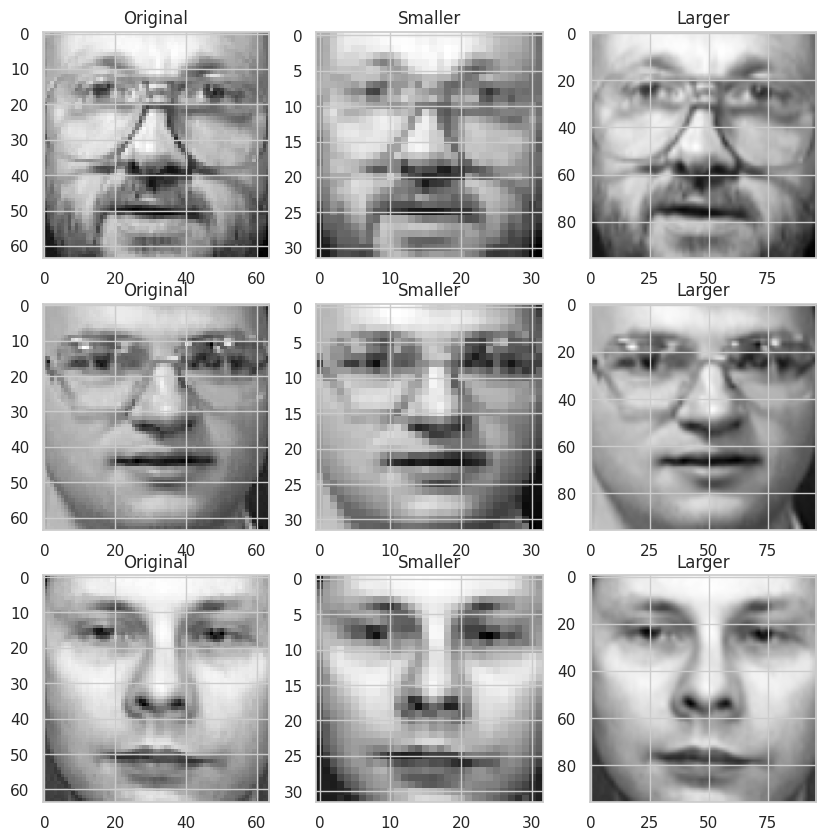

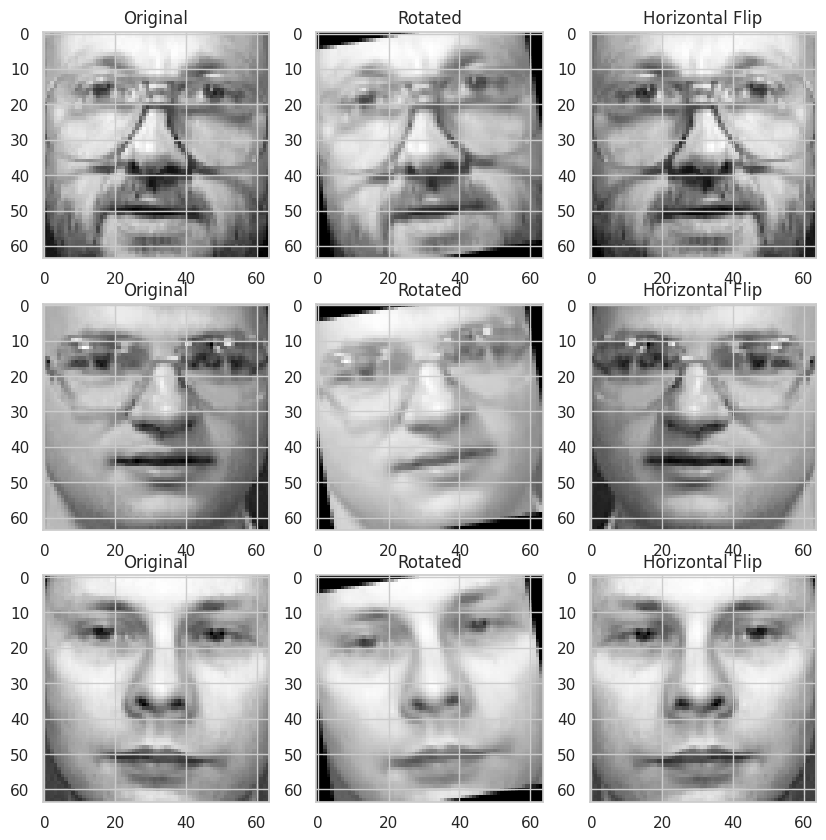

In [ ]:
#Task 9
import cv2

# Task 9.1
train_mean = X_train_img.mean()
train_std = X_train_img.std()

print("Train Mean: ", train_mean)
print("Train Std: ", train_std)

print("\n")

X_train_norm = (X_train_img - train_mean) / train_std
X_test_norm = (X_test_img - train_mean) / train_std

print("=" * 70)
print("1. Standardized Training Data")
print("Standardized Training Mean:", X_train_norm.mean())
print("Standardized Training Std:", X_train_norm.std())

print("\n")

print("2. Standardized Test Data")
print("Standardized Test Mean:", X_test_norm.mean())
print("Standardized Test Std:", X_test_norm.std())
print("=" * 70)

print("\n" * 2)



# Task 9.2
fig, ax = plt.subplots(3, 3, figsize = (10, 10))

for i in range(3):
  smaller = resize(images_train[i], (32, 32))
  larger = resize(images_train[i], (96, 96))

  ax[i, 0].imshow(images_train[i], cmap = "gray")
  ax[i, 0].set_title("Original")

  ax[i, 1].imshow(smaller, cmap = "gray")
  ax[i, 1].set_title("Smaller")

  ax[i, 2].imshow(larger, cmap = "gray")
  ax[i, 2].set_title("Larger")

plt.show()

print("\n" * 2)



# Task 9.3
fig, ax = plt.subplots(3, 3, figsize = (10, 10))

for i in range(3):

  original = images_train[i]
  rotated = rotate(original, angle=10)
  horizontal_flip = cv2.flip(original, 1)

  ax[i, 0].imshow(original, cmap = "gray")
  ax[i, 0].set_title("Original")

  ax[i, 1].imshow(rotated, cmap = "gray")
  ax[i, 1].set_title("Rotated")

  ax[i, 2].imshow(horizontal_flip, cmap = "gray")
  ax[i, 2].set_title("Horizontal Flip")

plt.show()



***Observation and Procedure:***

In this task, I first standardized the data in order to have the pixel values of the images on a more consistent scale. I obtained the values of the mean and standard deviation using the functions .mean() and .std(), and used those values to standardize the data using the formula for standardization.
After that, I performed resizing and augmentation on the subjects/images.

For resizing, I used the resize function provided by the skimage.transform library and resized it to the given value/s and displayed the function on a figure. I observed that the lower the resolution that its converted to, it becomes more pixelated and hard to see details, while the opposite goes for resizing a photo to a bigger resolution which gives it a cleaner look but it looks more unfocused and blurry.

For augmentation, I used two different augmentation functions based on the [1.2] Processing notes. The augmentation functions I used are horizontal flip and the rotation of the image.
- In the rotation augmentation, I used the skimage.transform library in order to use the rotate function which help me rotate the image to however angle I set it to.
- In the horizontal flip, I imported a library called cv2 in order to use or perform the horizontal flip based on the notes, and used its function.

I only applied the augmentation for the training images/data because the testing data should remain untainted and unprocessed which is used to test the model on, thus it should remain unchanged and represents unseen data. The same principle applies to the mean and standard deviation of the data, which I only obtained for the training data so that the testing data would not influence the preprocessing.



## Task 10 — Image Feature Engineering (10 pts)
Raw pixel values are one valid feature representation, but engineered descriptors are often more compact and more robust to small shifts in lighting or pose. Using your preprocessed training images:

1. Extract **Histogram of Oriented Gradients (HOG)** features (`skimage.feature.hog`) for at least 5 sample images, and visualize the HOG image (`visualize=True`) alongside the original.
2. Extract **edge-based** features using `skimage.filters.sobel` for the same samples and visualize the result.
3. Apply **PCA** to the flattened pixel data (fit on the training set only) and report how many components are needed to explain roughly 90-95% of the variance; visualize the first 5-10 principal components as "eigenfaces" (reshape each component back to 64×64).
4. Build a small comparison table (a `pandas.DataFrame` is fine) of feature dimensionality: raw flattened pixels vs. HOG feature vector vs. PCA components retained.


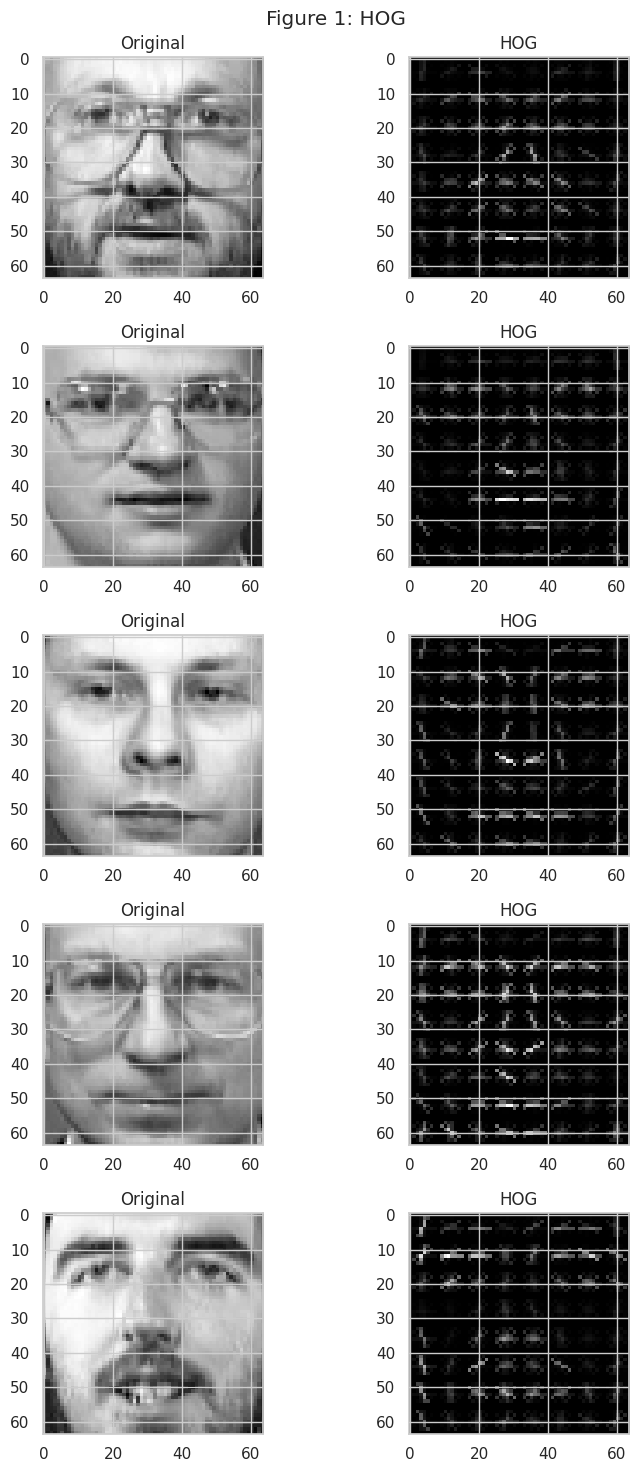

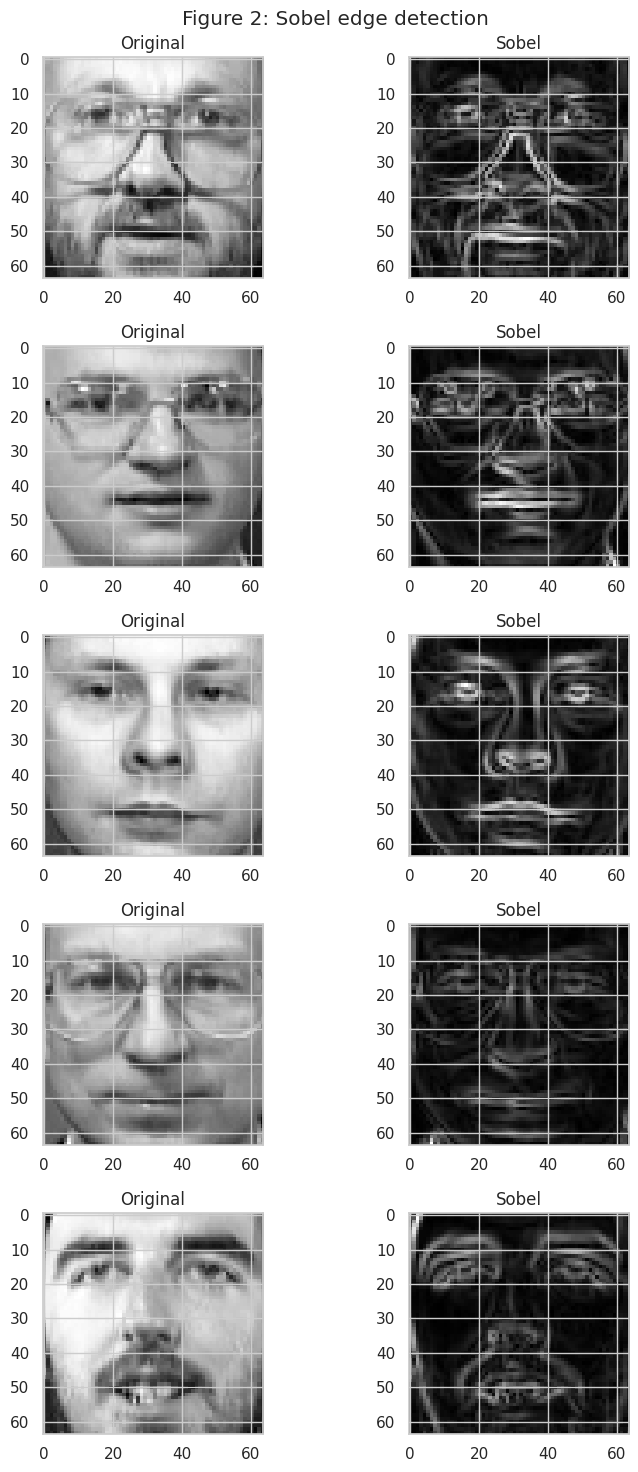




Original Dimensions: 4096
PCA Components: 111
Explained Variance: 0.9505931


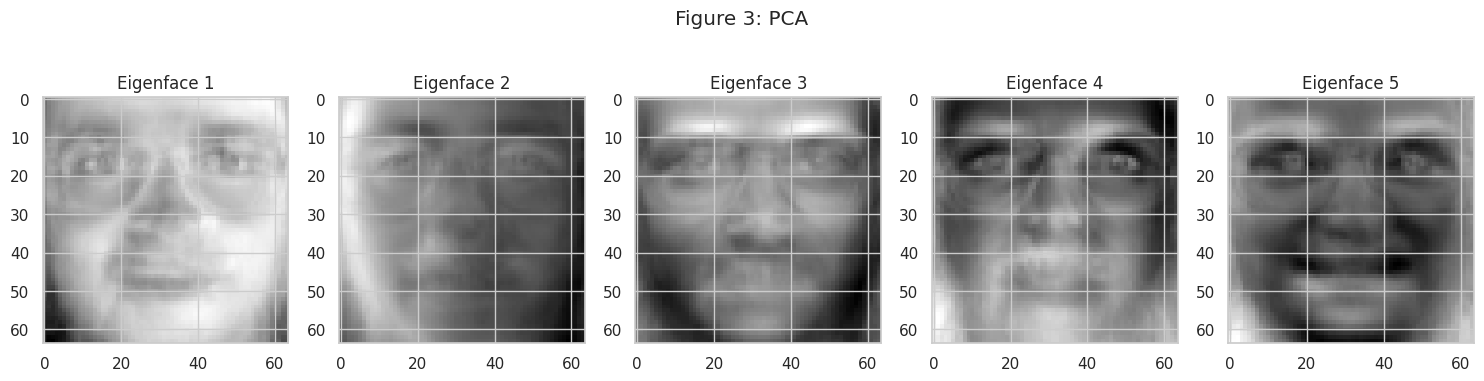




  Feature Representation  Dimensions
0             Raw Pixels        4096
1                    HOG        2916
2                    PCA         111


In [ ]:
#Task 10

# Task 10.1
fig, ax = plt.subplots(5, 2, figsize = (8, 15))

for i in range(5):

  hog_features, hog_image = hog(
      images_train[i],
      visualize = True
      )

  ax[i,0].imshow(images_train[i], cmap = "gray")
  ax[i,0].set_title("Original")

  ax[i,1].imshow(hog_image, cmap = "gray")
  ax[i,1].set_title("HOG")

plt.suptitle("Figure 1: HOG")
plt.tight_layout()
plt.show()

print("\n" * 2)




# Task 10.2
fig, ax = plt.subplots(5, 2, figsize = (8, 15))



for i in range(5):

  sobel_image = sobel(images_train[i])

  ax[i,0].imshow(images_train[i], cmap = "gray")
  ax[i,0].set_title("Original")

  ax[i,1].imshow(sobel_image, cmap = "gray")
  ax[i,1].set_title("Sobel")

plt.suptitle("Figure 2: Sobel edge detection")
plt.tight_layout()
plt.show()

print("\n" * 2)



# Task 10.3

pca = PCA(n_components = 0.95, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_norm)
X_test_pca = pca.transform(X_test_norm)

print("=" * 70)
print("Original Dimensions:", X_train_norm.shape[1])
print("PCA Components:", pca.n_components_)
print("Explained Variance:", pca.explained_variance_ratio_.sum())
print("=" * 70)



fig, ax = plt.subplots(1, 5, figsize = (15, 4))

for i in range(5):

  eigenface = pca.components_[i].reshape(64, 64)

  ax[i].imshow(eigenface, cmap = "gray")
  ax[i].set_title(f"Eigenface {i + 1}")

plt.suptitle("Figure 3: PCA")
plt.tight_layout()
plt.show()

print("\n" * 2)



# Task 10.4
comparison = pd.DataFrame({
    "Feature Representation": [
        "Raw Pixels",
        "HOG",
        "PCA"
    ],

    "Dimensions": [
        X_train_img.shape[1],
        len(hog_features),
        pca.n_components_
    ]
})

print(comparison)


***Observations and Procedure:***

In this task, I used three different methods to extract features present among images. The methods used in this task is HOG, Sobel edge detection, and PCA.

For HOG detection, I used the hog() function from the skimage.feature library to extract edges and shapes from the images used. We can see the features extracted on the figure 1: HOG which shows the sharp edges and some features that were detected on this method. In the comparason of the image extracted, we can see that there isn't much features that are obtained/extracted from the image.

For Sobel edge detection, I used the sobel() function in the same skimage.filters library to highlight the edges and changes in brightness found in the face images. This made facial outlines and bolder details more visible than the HOG detection.

Lastly, I used the PCA to reduce the number of features from the original flattened images. The Raw images had 4096 pixels, while the HOG have around 2916 features. The PCA reduced the data to only 111 components while still keeping a significant amount of 95% of the variance. This shows that PCA reduces the size of the data while maintaining/keeping most of its information.

## Task 11 — Written Reflection: Choosing an Image Feature Representation (10 pts)
**Observation / Justification:**
Based on Task 10, which representation (raw pixels, HOG, or PCA/eigenfaces) would you carry forward for downstream modeling, and why? Consider dimensionality, robustness to lighting/pose changes, interpretability, and how much of the "engineering" work each approach does automatically versus by hand.


***Observation and Procedure:***

For downstream modeling, I would preferrably choose the PCA method due to its efficiency and data compression whilst retaining most of its information from the original data. These advantages makes the data easier to work with and lighter on the storage load.

The Raw pixels from the original data contains all of the information, but they tend to have more redundant and unecessary features which constantly gets affected by changes in light or position. HOG focuses more on the edges and the shape of the images which is easier to understand compared to the PCA(showed in Task 10 figures 1-3) but still uses a large number of feature, having  2916 dimensions compared to 111 dimensions of PCA. PCA is less interpretable because each component is a combination of many pixel values, but I would still choose it because it reduces the dimensionality by a significant amount but still retains quite a lot of information, which makes it easier to process than HOG and the other feature detection.

---
## Submission Checklist
- All 11 tasks completed with working code and output visible
- Every scaler/imputer/encoder/selector/PCA is fit on **training data only** and merely applied (`.transform()`) to the test set — no exceptions
- No model (e.g., `MLPClassifier` or any other classifier) is trained anywhere in this notebook — this activity is preprocessing and feature engineering only
- Every plot has a title and axis labels
- Written justification included under each task (not just "I chose X" — explain **why**, with evidence from your own outputs or from Assignment 1.1)
- Notebook runs top-to-bottom without errors (`Kernel > Restart & Run All`)

## Grading Rubric (100 pts total)
| Task | Points |
|---|---|
| **Part A — Numerical Data** | |
| 1. Data Preparation and Leakage-Free Splitting | 5 |
| 2. Missing Value Imputation | 5 |
| 3. Outlier Detection and Treatment | 10 |
| 4. Feature Scaling | 10 |
| 5. Feature Engineering: Creation and Encoding | 10 |
| 6. Feature Transformation for Skew | 10 |
| 7. Feature Selection | 10 |
| **Part B — Image Data** | |
| 8. Image Dataset Preparation and Leakage-Free Splitting | 10 |
| 9. Image Preprocessing: Normalization and Augmentation | 10 |
| 10. Image Feature Engineering | 10 |
| 11. Written Reflection | 10 |
